# **Naive Early Fusion Experiment**
Poor results expected because:
- Huge dimensional vector as input -> Curse of dimensionality
- Simple concatenation of modalities

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2
import gc
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
import subprocess

from foundation.clinical import get_batch
from gbmhackathon.data import MosaicDataset
from gbmhackathon.s3_loader import load_s3, write_s3

In [3]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import GBMNet, PredictiveModule, ClinicalLinkageModule
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.model_saving import save_model
from gbmhackathon.training.cv import get_ci, get_cv_results, plot_results_cv, plot_cv_table
from gbmhackathon.s3_loader import load_s3

import os, time
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
torch.set_num_threads(32)
torch.get_num_threads()

32

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [6]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [7]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=0.0, normalize=True)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 114
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cuda 
Using device: cuda
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247], device='cuda:0')
Normalization applied successfully
Dataset size: 114


In [8]:
toy_batch = next(iter(dataloader))
#toy_batch

In [9]:
type(toy_batch)

tuple

In [10]:
toy_batch[2]['hne'].size()

torch.Size([114, 1536])

In [11]:
raw_emb = toy_batch[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([114, 1536])
spatial torch.Size([114, 64])
clinical torch.Size([114, 20])
wes torch.Size([114, 1790])
bulk torch.Size([114, 3072])
scRNA torch.Size([114, 3072])


In [12]:
raw_emb = toy_batch[2]

# 1) collecter les tenseurs et construire input_size_dict
tensors_to_concat = []
input_size_dict = {}

for mod, emb in raw_emb.items():
    if isinstance(emb, torch.Tensor):
        # on suppose que emb a la forme [batch_size, feature_size]
        input_size_dict[mod] = emb.size(1)
        tensors_to_concat.append(emb)
    else:
        # si tu veux voir ce qu'on skip :
        print(f"Skip {mod}: not a Tensor but {type(emb)}")

# 2) concaténation
# attention tous les emb doivent avoir le même batch_size (dim 0)
concat_emb = torch.cat(tensors_to_concat, dim=1)

print("Sizes by module:", input_size_dict)
print("Concatenated tensor size:", concat_emb.size())

Sizes by module: {'hne': 1536, 'spatial': 64, 'clinical': 20, 'wes': 1790, 'bulk': 3072, 'scRNA': 3072}
Concatenated tensor size: torch.Size([114, 9554])


In [13]:
X=concat_emb

In [14]:
Y=toy_batch[-2]

In [15]:
Y[:10]

tensor([[-1.0361, -0.8726,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [-0.5524, -0.4225,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [ 1.3903,  0.1020,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [-0.9366, -0.5267,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [ 2.6006,  0.1950,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [-0.5325, -1.1107,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [-0.2100,  0.0648,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [-0.8012, -0.6383,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [-0.3593,  0.1615,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [-0.4569, -0.8615,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000]],
       device='cuda:0')

In [16]:
y_reg=Y[:,:2]
y_cat=Y[:,2:]

In [17]:
print(y_reg.size(),y_cat.size())

torch.Size([114, 2]) torch.Size([114, 5])


In [18]:
print(X.size(),Y.size())

torch.Size([114, 9554]) torch.Size([114, 7])


In [19]:
del dataset

In [20]:
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, f1_score, root_mean_squared_error
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import ShuffleSplit


def train_GBT(splitter):
    # se_sums = np.zeros(2)
    # f1_rec_sums = np.zeros(1)
    # f1_mgmt_sums = np.zeros(1)

    all_rmse1 = []
    all_rmse2 = []
    all_f1_rec  = []
    all_f1_mgmt  = []
    
    n_splits = splitter.get_n_splits(X)
    t0 = time.time()
    for i, (train_idx, test_idx) in enumerate(splitter.split(X), 1):
        X_train, X_test = X[train_idx].cpu(), X[test_idx].cpu()
        y_reg_train, y_reg_test = y_reg[train_idx].cpu(), y_reg[test_idx].cpu()
        y_rec_train, y_rec_test = torch.argmax(y_cat[train_idx,:2], dim=1).cpu(), torch.argmax(y_cat[test_idx,:2], dim=1).cpu()
        y_mgmt_train, y_mgmt_test = torch.argmax(y_cat[train_idx,2:], dim=1).cpu(), torch.argmax(y_cat[test_idx,2:], dim=1).cpu()
    
        # reg_mt = MultiOutputRegressor(
        #     HistGradientBoostingRegressor(max_iter=100, early_stopping=True),
        #     n_jobs=-1)
        reg_os = HistGradientBoostingRegressor(max_iter=100, early_stopping=True)
        reg_pfs = HistGradientBoostingRegressor(max_iter=100, early_stopping=True)
        clf_rec = HistGradientBoostingClassifier(max_iter=100, early_stopping=True)
        clf_mgmt = HistGradientBoostingClassifier(max_iter=100, early_stopping=True)
    
        # Training
        # reg_mt.fit(X_train, y_reg_train)
        reg_os.fit(X_train, y_reg_train[:,0])
        reg_pfs.fit(X_train, y_reg_train[:,1])
        clf_rec.fit(X_train, y_rec_train)
        clf_mgmt.fit(X_train, y_mgmt_train)
    
        # Prediction
        # y_reg_pred = reg_mt.predict(X_test)
        y_reg_os = reg_os.predict(X_test)
        y_reg_pfs = reg_pfs.predict(X_test)
        y_rec_pred = clf_rec.predict(X_test)
        y_mgmt_pred = clf_mgmt.predict(X_test)
    
        # # Accumulation of metrics
        # for k in range(2):
        #     rmse = np.sqrt(np.mean((y_reg_pred[:, k] - y_reg_test[:, k].cpu().numpy())**2))
        #     if k == 0:
        #         all_rmse1.append(rmse)
        #     else:
        #         all_rmse2.append(rmse)
        #     # se_sums[k] += np.sum((y_reg_pred[:, k] - y_reg_test[:, k].cpu().numpy())**2)
        all_rmse1.append(root_mean_squared_error(y_reg_os, y_reg_test[:,0].cpu().numpy()))
        all_rmse2.append(root_mean_squared_error(y_reg_pfs, y_reg_test[:,1].cpu().numpy()))
        all_f1_rec.append(f1_score(y_rec_test, y_rec_pred, average='weighted', zero_division=0))
        all_f1_mgmt.append(f1_score(y_mgmt_test, y_mgmt_pred, average='weighted', zero_division=0))
        
        # f1_rec_sums += f1_score(y_rec_test, y_rec_pred, average='weighted', zero_division=0)
        # f1_mgmt_sums += f1_score(y_mgmt_test, y_mgmt_pred, average='weighted', zero_division=0)
    
        print(f"Iteration {i}/{n_splits}", end="\r")
    
    # # Averages over all Monte Carlo iterations
    # avg_rmse = np.sqrt(se_sums / (n_splits * len(test_idx)))
    # avg_f1_rec = f1_rec_sums / n_splits
    # avg_f1_mgmt = f1_mgmt_sums / n_splits
    # print("\nMultitâche CV → RMSE:", avg_rmse, "— F1 Recurrency:", avg_f1_rec, "— F1 MGMT Methylation:", avg_f1_mgmt)
    runtime = time.time() - t0
    run_name = f"naive_early_fusion_gbt"
    reg_dict = {'os':all_rmse1, 'pfs':all_rmse2}
    clf_dict = {'recurrency':all_f1_rec, 'mgmt':all_f1_mgmt}
    return get_cv_results(reg_dict, clf_dict, run_name, time=runtime, save=True)
    # # Calcul des moyennes sur tous les folds
    # ci_rmse1 =get_ci(all_rmse1)
    # ci_rmse2 =get_ci(all_rmse2)
    # ci_f1_rec  = get_ci(all_f1_rec)
    # ci_f1_mgmt  = get_ci(all_f1_mgmt)

    # # Affichage final des moyennes globales
    # print("=== Moyennes sur tous les folds ===")
    # print(f"RMSE CI95% for os (low, mean, high): [{[f'{val:.4f}' for val in ci_rmse1]}]")
    # print(f"RMSE CI95% for pfs (low, mean, high): [{[f'{val:.4f}' for val in ci_rmse2]}]")
    # print(f"F1 CI95% for Recurrency (low, mean, high): [{[f'{val:.4f}' for val in ci_f1_rec]}]")
    # print(f"F1 CI95% for MGMT Methylation (low, mean, high): [{[f'{val:.4f}' for val in ci_f1_mgmt]}]")

def make_dummy(splitter):
    # se_sums = np.zeros(2)
    # f1_rec_sums = np.zeros(1)
    # f1_mgmt_sums = np.zeros(1)

    all_rmse1 = []
    all_rmse2 = []
    all_f1_rec  = []
    all_f1_mgmt  = []
    
    n_splits = splitter.get_n_splits(X)
    t0 = time.time()
    for i, (train_idx, test_idx) in enumerate(splitter.split(X), 1):
        X_train, X_test = X[train_idx].cpu(), X[test_idx].cpu()
        y_reg_train, y_reg_test = y_reg[train_idx].cpu(), y_reg[test_idx].cpu()
        y_rec_train, y_rec_test = torch.argmax(y_cat[train_idx,:2], dim=1).cpu(), torch.argmax(y_cat[test_idx,:2], dim=1).cpu()
        y_mgmt_train, y_mgmt_test = torch.argmax(y_cat[train_idx,2:], dim=1).cpu(), torch.argmax(y_cat[test_idx,2:], dim=1).cpu()
    
        # Prediction
        # y_reg_pred = reg_mt.predict(X_test)
        y_reg_os = np.random.randn(X_test.shape[0])*y_reg_train[:,0].cpu().detach().numpy().std() + y_reg_train[:,0].cpu().detach().numpy().mean()
        y_reg_pfs = np.random.randn(X_test.shape[0])*y_reg_train[:,1].cpu().detach().numpy().std() + y_reg_train[:,1].cpu().detach().numpy().mean()
        y_rec_pred = np.random.randint(0,2, X_test.shape[0])
        y_mgmt_pred = np.random.randint(0,3, X_test.shape[0])
        # print(y_reg_os.max(), y_reg_os.min())
        # print(y_reg_train[:,0].max(), y_reg_train[:,0].min()) 
        # print(y_mgmt_pred)
        # # Accumulation of metrics
        # for k in range(2):
        #     rmse = np.sqrt(np.mean((y_reg_pred[:, k] - y_reg_test[:, k].cpu().numpy())**2))
        #     if k == 0:
        #         all_rmse1.append(rmse)
        #     else:
        #         all_rmse2.append(rmse)
        #     # se_sums[k] += np.sum((y_reg_pred[:, k] - y_reg_test[:, k].cpu().numpy())**2)
        all_rmse1.append(root_mean_squared_error(y_reg_os, y_reg_test[:,0].cpu().numpy()))
        all_rmse2.append(root_mean_squared_error(y_reg_pfs, y_reg_test[:,1].cpu().numpy()))
        all_f1_rec.append(f1_score(y_rec_test, y_rec_pred, average='weighted', zero_division=0))
        all_f1_mgmt.append(f1_score(y_mgmt_test, y_mgmt_pred, average='weighted', zero_division=0))
        
        # f1_rec_sums += f1_score(y_rec_test, y_rec_pred, average='weighted', zero_division=0)
        # f1_mgmt_sums += f1_score(y_mgmt_test, y_mgmt_pred, average='weighted', zero_division=0)
    
        print(f"Iteration {i}/{n_splits}", end="\r")
    
    # # Averages over all Monte Carlo iterations
    # avg_rmse = np.sqrt(se_sums / (n_splits * len(test_idx)))
    # avg_f1_rec = f1_rec_sums / n_splits
    # avg_f1_mgmt = f1_mgmt_sums / n_splits
    # print("\nMultitâche CV → RMSE:", avg_rmse, "— F1 Recurrency:", avg_f1_rec, "— F1 MGMT Methylation:", avg_f1_mgmt)
    runtime = time.time() - t0
    run_name = f"random_baseline"
    reg_dict = {'os':all_rmse1, 'pfs':all_rmse2}
    clf_dict = {'recurrency':all_f1_rec, 'mgmt':all_f1_mgmt}
    return get_cv_results(reg_dict, clf_dict, run_name, time=runtime, save=True)

def make_linear(splitter):
    # se_sums = np.zeros(2)
    # f1_rec_sums = np.zeros(1)
    # f1_mgmt_sums = np.zeros(1)

    all_rmse1 = []
    all_rmse2 = []
    all_f1_rec  = []
    all_f1_mgmt  = []
    
    n_splits = splitter.get_n_splits(X)
    t0 = time.time()
    for i, (train_idx, test_idx) in enumerate(splitter.split(X), 1):
        X_train, X_test = X[train_idx].cpu(), X[test_idx].cpu()
        y_reg_train, y_reg_test = y_reg[train_idx].cpu(), y_reg[test_idx].cpu()
        y_rec_train, y_rec_test = torch.argmax(y_cat[train_idx,:2], dim=1).cpu(), torch.argmax(y_cat[test_idx,:2], dim=1).cpu()
        y_mgmt_train, y_mgmt_test = torch.argmax(y_cat[train_idx,2:], dim=1).cpu(), torch.argmax(y_cat[test_idx,2:], dim=1).cpu()

        reg_os = LinearRegression()
        reg_pfs = LinearRegression()
        clf_rec = LogisticRegression()
        clf_mgmt = SVC(kernel='linear')
        
        # Training
        # reg_mt.fit(X_train, y_reg_train)
        reg_os.fit(X_train, y_reg_train[:,0])
        reg_pfs.fit(X_train, y_reg_train[:,1])
        clf_rec.fit(X_train, y_rec_train)
        clf_mgmt.fit(X_train, y_mgmt_train)
    
        # Prediction
        # y_reg_pred = reg_mt.predict(X_test)
        y_reg_os = reg_os.predict(X_test)
        y_reg_pfs = reg_pfs.predict(X_test)
        y_rec_pred = clf_rec.predict(X_test)
        y_mgmt_pred = clf_mgmt.predict(X_test)
        # print(y_reg_os.max(), y_reg_os.min())
        # print(y_reg_train[:,0].max(), y_reg_train[:,0].min()) 
        # print(y_mgmt_pred)
        # # Accumulation of metrics
        # for k in range(2):
        #     rmse = np.sqrt(np.mean((y_reg_pred[:, k] - y_reg_test[:, k].cpu().numpy())**2))
        #     if k == 0:
        #         all_rmse1.append(rmse)
        #     else:
        #         all_rmse2.append(rmse)
        #     # se_sums[k] += np.sum((y_reg_pred[:, k] - y_reg_test[:, k].cpu().numpy())**2)
        all_rmse1.append(root_mean_squared_error(y_reg_os, y_reg_test[:,0].cpu().numpy()))
        all_rmse2.append(root_mean_squared_error(y_reg_pfs, y_reg_test[:,1].cpu().numpy()))
        all_f1_rec.append(f1_score(y_rec_test, y_rec_pred, average='weighted', zero_division=0))
        all_f1_mgmt.append(f1_score(y_mgmt_test, y_mgmt_pred, average='weighted', zero_division=0))
        
        # f1_rec_sums += f1_score(y_rec_test, y_rec_pred, average='weighted', zero_division=0)
        # f1_mgmt_sums += f1_score(y_mgmt_test, y_mgmt_pred, average='weighted', zero_division=0)
    
        print(f"Iteration {i}/{n_splits}", end="\r")

    # # Averages over all Monte Carlo iterations
    # avg_rmse = np.sqrt(se_sums / (n_splits * len(test_idx)))
    # avg_f1_rec = f1_rec_sums / n_splits
    # avg_f1_mgmt = f1_mgmt_sums / n_splits
    # print("\nMultitâche CV → RMSE:", avg_rmse, "— F1 Recurrency:", avg_f1_rec, "— F1 MGMT Methylation:", avg_f1_mgmt)
    runtime = time.time() - t0
    run_name = f"linear_baseline"
    reg_dict = {'os':all_rmse1, 'pfs':all_rmse2}
    clf_dict = {'recurrency':all_f1_rec, 'mgmt':all_f1_mgmt}
    return get_cv_results(reg_dict, clf_dict, run_name, time=runtime, save=True)

In [21]:
X.shape

torch.Size([114, 9554])

## **GradientBoosting: Monte Carlo Cross-Validation**

In [22]:
from sklearn.model_selection import ShuffleSplit

n_splits = 30  # Number of Monte Carlo iterations
test_size = 0.2  # Fraction of data to use for testing in each split
random_state = 62  # For reproducibility

mc_cv = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

In [23]:
train_GBT(mc_cv)

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,naive_early_fusion_gbt,30,166.370216,0.865291,0.914396,0.962513,0.911589,0.967965,1.031145,0.490042,0.523008,0.552464,0.432154,0.469956,0.500935,1.882361,0.992964,0.229838,0.265707


## Having a dummy baseline will be useful to see if any approaches actually yields better results than random.

In [24]:
make_dummy(mc_cv)

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,random_baseline,30,0.207395,1.371988,1.4432,1.515539,1.322599,1.40372,1.495755,0.466227,0.48681,0.506255,0.308016,0.35556,0.394127,2.84692,0.842371,0.222822,0.32441


In [25]:
make_linear(mc_cv)

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,linear_baseline,30,79.811294,0.914694,0.946422,0.98204,0.899311,0.943456,0.988823,0.532217,0.568874,0.59927,0.451443,0.489111,0.531897,1.889877,1.057985,0.166035,0.28236


# MLP: Cross-Validation

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import numpy as np
from sklearn.model_selection import LeaveOneOut, ShuffleSplit
from sklearn.metrics import f1_score

In [27]:
class TabularDataset(Dataset):
    """
    Dataset PyTorch pour des données tabulaires.
    X: array-like de shape (n_samples, n_features)
    Y: array-like de shape (n_samples, 5) où les 3 premières colonnes sont continues,
       et les 2 dernières sont catégorielles (entiers).
    """
    def __init__(self, X, Y, device='cpu'):
        self.X = torch.from_numpy(np.asarray(X)).float() if isinstance(X, np.ndarray) else X.float()
        self.Y = torch.from_numpy(np.asarray(Y)) if isinstance(Y, np.ndarray) else Y
        self.device = device

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y_cont = self.Y[idx, :2].float()
        y_cat = self.Y[idx, 2:].long()
        return x.to(self.device), y_cont.to(self.device), y_cat.to(self.device)

# def get_loo_loaders(X, Y, batch_size=32, device='cpu'):
#     """
#     Renvoie un itérateur de folds Leave-One-Out.
#     Pour chaque itération, on obtient train_loader, val_loader.
#     """
# #    cpu_count = os.cpu_count() or 1
#     dataset = TabularDataset(X, Y, device=device)
#     loo = LeaveOneOut()
#     for train_idx, val_idx in loo.split(X):
#         train_subset = Subset(dataset, train_idx)
#         val_subset = Subset(dataset, val_idx)

#         train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
#         val_loader = DataLoader(val_subset, batch_size=1, shuffle=False)

        
# #        train_loader = DataLoader(
# #            train_subset,
# #            batch_size=batch_size,
# #            shuffle=True,
# #            num_workers=cpu_count,  # parallélisation du chargement
# #            pin_memory=(device!='cpu')  # épingle en mémoire pour GPU
# #        )
# #        val_loader = DataLoader(
# #            val_subset,
# #            batch_size=1,
# #            shuffle=False,
# #            num_workers=cpu_count//2,
# #            pin_memory=(device!='cpu')
# #        )
#         yield train_loader, val_loader

n_splits = 30  # Number of Monte Carlo iterations
test_size = 0.2  # Fraction of data to use for testing in each split
random_state = 62  # For reproducibility
def get_mccv_loaders(X, Y, batch_size=32, device='cpu'):
    """
    Renvoie un itérateur de folds Leave-One-Out.
    Pour chaque itération, on obtient train_loader, val_loader.
    """
#    cpu_count = os.cpu_count() or 1
    dataset = TabularDataset(X, Y, device=device)
    mccv =  ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
    for train_idx, val_idx in mccv.split(X):
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=dataset.device))
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, generator=torch.Generator(device=dataset.device))
        yield train_loader, val_loader

In [28]:
in_size = X.shape[1]
norm_fn = nn.BatchNorm1d
dropout = 0.2
layers = [in_size,1024,512,128]
act_fn = [nn.GELU] * (len(layers) - 1) + [None]
reg_head_cfg = {"layers": layers + [1],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn": act_fn,
        "norm_layer":norm_fn,
        "device":device}
binary_clf_head_cfg = {"layers": layers + [2],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn": act_fn,
        "norm_layer":norm_fn,
        "device":device}
multi_clf_head_cfg = {"layers": layers + [3],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn": act_fn,
        "norm_layer":norm_fn,
        "device":device}

In [29]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": binary_clf_head_cfg}
mgmt_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": multi_clf_head_cfg}

In [30]:
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "recurrency":recurrency_head_cfg,
                  "mgmt":mgmt_head_cfg}}

In [31]:
def eval_epoch(model, loader, device):
    """
    Évaluation sans rétropropagation. Calcule RMSE et F1 comme train_epoch,
    mais passe en mode eval et n'appelle pas backward/step.
    """
    model.eval()
    se_sums = [0.0, 0.0]
    n_samples = 0
    all_preds_rec, all_labels_rec = [], []
    all_preds_mgmt, all_labels_mgmt = [], []
    # all_preds_a, all_labels_a = [], []
    # all_preds_b, all_labels_b = [], []

    criterion_mse = nn.MSELoss()
    criterion_ce = nn.CrossEntropyLoss()

    for X_batch, y_cont, y_cat in loader:
        out_list = list(model(X_batch).values()) if not isinstance(model, ClinicalLinkageModule) else list(model(X_batch, None, None).values())
        o1, o2, logits = out_list[0], out_list[1], out_list[2:]
        logits_rec, logits_mgmt = logits[0], logits[1]
        
        y1, y2 = y_cont[:, 0], y_cont[:, 1]
        # y_a, y_b = y_cat[:, 0], y_cat[:, 1]
        y_cat_rec = y_cat[:,:2].to(torch.half)
        y_cat_mgmt = y_cat[:,2:].to(torch.half)
        
        loss1 = criterion_mse(o1.squeeze(), y1)
        loss2 = criterion_mse(o2.squeeze(), y2)
        loss3 = criterion_ce(logits_rec, y_cat_rec)
        loss4 = criterion_ce(logits_mgmt, y_cat_mgmt)
        # loss4a = criterion_ce(logits_a, y_a)
        # loss4b = criterion_ce(logits_b, y_b)

        batch_size = X_batch.size(0)
        n_samples += batch_size
        se_sums[0] += loss1.item()
        se_sums[1] += loss2.item()

        preds_rec = torch.argmax(logits_rec, dim=1).cpu().numpy()
        all_preds_rec.extend(preds_rec)
        all_labels_rec.extend(torch.argmax(y_cat_rec, dim=1).cpu().numpy())      # preds_a = torch.argmax(logits_a, dim=1).cpu().numpy()
        
        preds_mgmt = torch.argmax(logits_mgmt, dim=1).cpu().numpy()
        all_preds_mgmt.extend(preds_mgmt)
        all_labels_mgmt.extend(torch.argmax(y_cat_mgmt, dim=1).cpu().numpy())
        # preds_b = torch.argmax(logits_b, dim=1).cpu().numpy()
        # all_preds_a.extend(preds_a)
        # all_preds_b.extend(preds_b)
        # all_labels_a.extend(y_a.cpu().numpy())
        # all_labels_b.extend(y_b.cpu().numpy())

    rmse1 = np.sqrt(se_sums[0] / n_samples)
    rmse2 = np.sqrt(se_sums[1] / n_samples)
    f1_rec = f1_score(all_labels_rec, all_preds_rec, average='weighted')
    f1_mgmt = f1_score(all_labels_mgmt, all_preds_mgmt, average='weighted')
    # f1_a = f1_score(all_labels_a, all_preds_a, average='macro')
    # f1_b = f1_score(all_labels_b, all_preds_b, average='macro')
    return {'rmse1': rmse1, 'rmse2': rmse2, 'f1_rec': f1_rec, 'f1_mgmt': f1_mgmt}



In [32]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    se_sums = [0.0, 0.0]
    n_samples = 0
    all_preds_rec, all_labels_rec = [], []
    all_preds_mgmt, all_labels_mgmt = [], []

    criterion_mse = nn.MSELoss()
    criterion_ce = nn.CrossEntropyLoss()

    n_batches = len(loader)
    for batch_idx, (X_batch, y_cont, y_cat) in enumerate(loader, 1):
        # Affichage de l'avancement par batch
        #print(f"  Batch {batch_idx}/{n_batches}", end="\r")

        optimizer.zero_grad()
        out_list = list(model(X_batch).values()) if not isinstance(model, ClinicalLinkageModule) else list(model(X_batch, None, None).values())
        o1, o2, logits = out_list[0], out_list[1], out_list[2:]
        logits_rec, logits_mgmt = logits[0], logits[1]
        
        y1, y2 = y_cont[:, 0], y_cont[:, 1]
        # y_a, y_b = y_cat[:, 0], y_cat[:, 1]
        y_cat_rec = y_cat[:,:2].to(torch.half)
        y_cat_mgmt = y_cat[:,2:].to(torch.half)

        loss1 = criterion_mse(o1.squeeze(), y1)
        loss2 = criterion_mse(o2.squeeze(), y2)
        loss3 = criterion_ce(logits_rec, y_cat_rec)
        loss4 = criterion_ce(logits_mgmt, y_cat_mgmt)
        

        loss = loss1 + loss2 + loss3 + loss4
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        n_samples += batch_size
        se_sums[0] += loss1.item()
        se_sums[1] += loss2.item()

        preds_rec = torch.argmax(logits_rec, dim=1).cpu().numpy()
        all_preds_rec.extend(preds_rec)
        all_labels_rec.extend(torch.argmax(y_cat_rec, dim=1).cpu().numpy()) 
        
        preds_mgmt = torch.argmax(logits_mgmt, dim=1).cpu().numpy()
        all_preds_mgmt.extend(preds_mgmt)
        all_labels_mgmt.extend(torch.argmax(y_cat_mgmt, dim=1).cpu().numpy()) 

    rmse1 = np.sqrt(se_sums[0] / n_samples)
    rmse2 = np.sqrt(se_sums[1] / n_samples)
    f1_rec = f1_score(all_labels_rec, all_preds_rec, average='weighted')
    f1_mgmt = f1_score(all_labels_mgmt, all_preds_mgmt, average='weighted')
    return {'rmse1': rmse1, 'rmse2': rmse2, 'f1_rec': f1_rec, 'f1_mgmt': f1_mgmt}


def fit(model_class, model_cfg, X, Y, device, get_loaders_func, num_epochs=20, batch_size=32, scheduler=None, suffix=None):
    """
    Entraîne le modèle avec LOOCV et affiche des statistiques globales.
    Affiche uniquement deux lignes actualisables : une pour le fold courant et une pour l'epoch.
    """
    history = []
    total_folds = len([el for el in enumerate(
            get_loaders_func(X, Y, batch_size=batch_size, device=device), start=1)])
    # Préparation des listes pour statistiques globales
    t0 = time.time()
    for fold, (train_loader, val_loader) in enumerate(
            get_loaders_func(X, Y, batch_size=batch_size, device=device), start=1):
        model = instantiate(model_cfg, model_class)
        # Instanciation du modèle avec layers
        # layers = [X.shape[1], 1024, 512, 64]
        # model = SimpleMLP(layers=layers).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
        # Affichage du fold courant, actualisable
        print(f"Fold {fold}/{total_folds}")
        for epoch in range(1, num_epochs + 1):
            # Réécrit la ligne pour l'epoch en cours
            print(f"Epoch {epoch}/{num_epochs}.", end='\r')
            train_metrics = train_epoch(model, train_loader, optimizer, device)
            val_metrics = eval_epoch(model, val_loader, device)
            if epoch == 1 or epoch == num_epochs//2 or epoch == num_epochs:
                print(f"Epoch {epoch} training metrics", train_metrics)
                print(f"Epoch {epoch} validation metrics", val_metrics)
            if scheduler:
                scheduler.step(val_metrics['rmse1'])
        # À la fin des epochs, on passe à la ligne suivante
        print()
        history.append({'fold': fold, 'train': train_metrics, 'val': val_metrics})

    # Calcul des moyennes sur tous les folds
    all_rmse1 = [h['val']['rmse1'] for h in history]
    all_rmse2 = [h['val']['rmse2'] for h in history]
    all_f1_rec  = [h['val']['f1_rec']   for h in history]
    all_f1_mgmt  = [h['val']['f1_mgmt']   for h in history]

    runtime = time.time() - t0
    run_name = f"naive_early_fusion_nn" if suffix is None else f"naive_early_fusion_nn_{suffix}"
    reg_dict = {'os':all_rmse1, 'pfs':all_rmse2}
    clf_dict = {'recurrency':all_f1_rec, 'mgmt':all_f1_mgmt}
    return get_cv_results(reg_dict, clf_dict, run_name, time=runtime, save=True), model
    # ci_rmse1 =get_ci(all_rmse1)
    # ci_rmse2 =get_ci(all_rmse2)
    # ci_f1_rec  = get_ci(all_f1_rec)
    # ci_f1_mgmt  = get_ci(all_f1_mgmt)

    # # Affichage final des moyennes globales
    # print("=== Moyennes sur tous les folds ===")
    # print(f"RMSE CI95% for os (low, mean, high): [{[f'{val:.4f}' for val in ci_rmse1]}]")
    # print(f"RMSE CI95% for pfs (low, mean, high): [{[f'{val:.4f}' for val in ci_rmse2]}]")
    # print(f"F1 CI95% for Recurrency (low, mean, high): [{[f'{val:.4f}' for val in ci_f1_rec]}]")
    # print(f"F1 CI95% for MGMT Methylation (low, mean, high): [{[f'{val:.4f}' for val in ci_f1_mgmt]}]")
    # return history


In [33]:
# class SimpleMLP(nn.Module):
#     """
#     MLP multitâche avec architecture configurable via `layers`.
#     `layers` est une liste d'entiers [in_dim, h1, h2, ..., hN].
#     """
#     def __init__(self, layers):
#         super().__init__()
#         modules = []
#         for in_dim, out_dim in zip(layers[:-1], layers[1:]):
#             modules.append(nn.Linear(in_dim, out_dim))
#             modules.append(nn.ReLU())
#         self.shared = nn.Sequential(*modules)
#         last = layers[-1]
#         self.out1 = nn.Linear(last, 1)
#         self.out2 = nn.Linear(last, 1)
#         self.out3 = nn.Linear(last, 1)
#         self.clf = nn.Linear(last, 2)

#     def forward(self, x):
#         h = self.shared(x)
#         return (
#             self.out1(h),
#             self.out2(h),
#             self.out3(h),
#             self.clf(h)
#         )

## **MLP: Monte Carlo Cross-Validation**

In [34]:
NN_BATCH = 16

In [35]:
if device == 'cuda':
    gc.collect()
    torch.cuda.empty_cache()
history, last_model = fit(PredictiveModule, predictive_cfg, X, Y, device, get_mccv_loaders, 
              num_epochs=55, 
              batch_size=NN_BATCH)

Using device(prediction head) : cuda
No potential residual connections found
Using device(prediction head) : cuda
No potential residual connections found
Using device(prediction head) : cuda
No potential residual connections found
Using device(prediction head) : cuda
No potential residual connections found
Fold 1/30
Epoch 1 training metrics {'rmse1': np.float64(0.3528736467516033), 'rmse2': np.float64(0.3478266548839506), 'f1_rec': 0.4622369622369622, 'f1_mgmt': 0.34148974567093027}
Epoch 1 validation metrics {'rmse1': np.float64(0.2937594681306991), 'rmse2': np.float64(0.38442321237655463), 'f1_rec': 0.3702341137123746, 'f1_mgmt': 0.3354037267080745}
Epoch 27 training metrics {'rmse1': np.float64(0.11406430687048182), 'rmse2': np.float64(0.10083791732104971), 'f1_rec': 0.9565656222002972, 'f1_mgmt': 0.9695190055845793}
Epoch 27 validation metrics {'rmse1': np.float64(0.5789323519414761), 'rmse2': np.float64(0.23011861416583362), 'f1_rec': 0.424016563146998, 'f1_mgmt': 0.36338672768878

In [37]:
save_model(last_model, '../saved_models/naive_early_fusion_nn.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/naive_early_fusion_nn.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_naive_early_fusion_nn.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/naive_early_fusion_nn.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_naive_early_fusion_nn.ckpt'))

In [38]:
os.makedirs('../experiments/early_fusion_embeddings', exist_ok=True)
with open('../experiments/early_fusion_embeddings/naive.pkl', 'wb') as f:
    pkl.dump(raw_emb, f)

## With Refinement Block

In [39]:
refinement_cfg = {"emb_size": in_size,
                "cross_modality_heads": 1,
                "cross_mods_fc_size": 1024,
                "avail_mods_fc_size": 128,
                "avail_mods_len":len(name_emb_dict),
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": dropout,
                "device": device}

In [40]:
clm_cfg = {"refinement_cfg":refinement_cfg,
           "predictive_cfg":predictive_cfg}

In [41]:
if device == 'cuda':
    gc.collect()
    torch.cuda.empty_cache()
    print("Cleared GPU")
history, last_model = fit(ClinicalLinkageModule, clm_cfg, X, Y, device, get_mccv_loaders, 
              num_epochs=55, 
              batch_size=NN_BATCH, 
              suffix='with_refinement')

Cleared GPU
Using device: cuda
Using device(prediction head) : cuda
No potential residual connections found
Using device(prediction head) : cuda
No potential residual connections found
Using device(prediction head) : cuda
No potential residual connections found
Using device(prediction head) : cuda
No potential residual connections found
Fold 1/30
Epoch 1 training metrics {'rmse1': np.float64(0.35893258366848324), 'rmse2': np.float64(0.3390503401180895), 'f1_rec': 0.5166262309119452, 'f1_mgmt': 0.38388572820432526}
Epoch 1 validation metrics {'rmse1': np.float64(0.9031043412870332), 'rmse2': np.float64(0.8412403617211627), 'f1_rec': 0.2635046113306983, 'f1_mgmt': 0.40821256038647347}
Epoch 27 training metrics {'rmse1': np.float64(0.19875367466319394), 'rmse2': np.float64(0.18070765015662985), 'f1_rec': 0.7954596616152478, 'f1_mgmt': 0.7180489865405416}
Epoch 27 validation metrics {'rmse1': np.float64(0.42556642241409115), 'rmse2': np.float64(0.32016338060944677), 'f1_rec': 0.29907773386

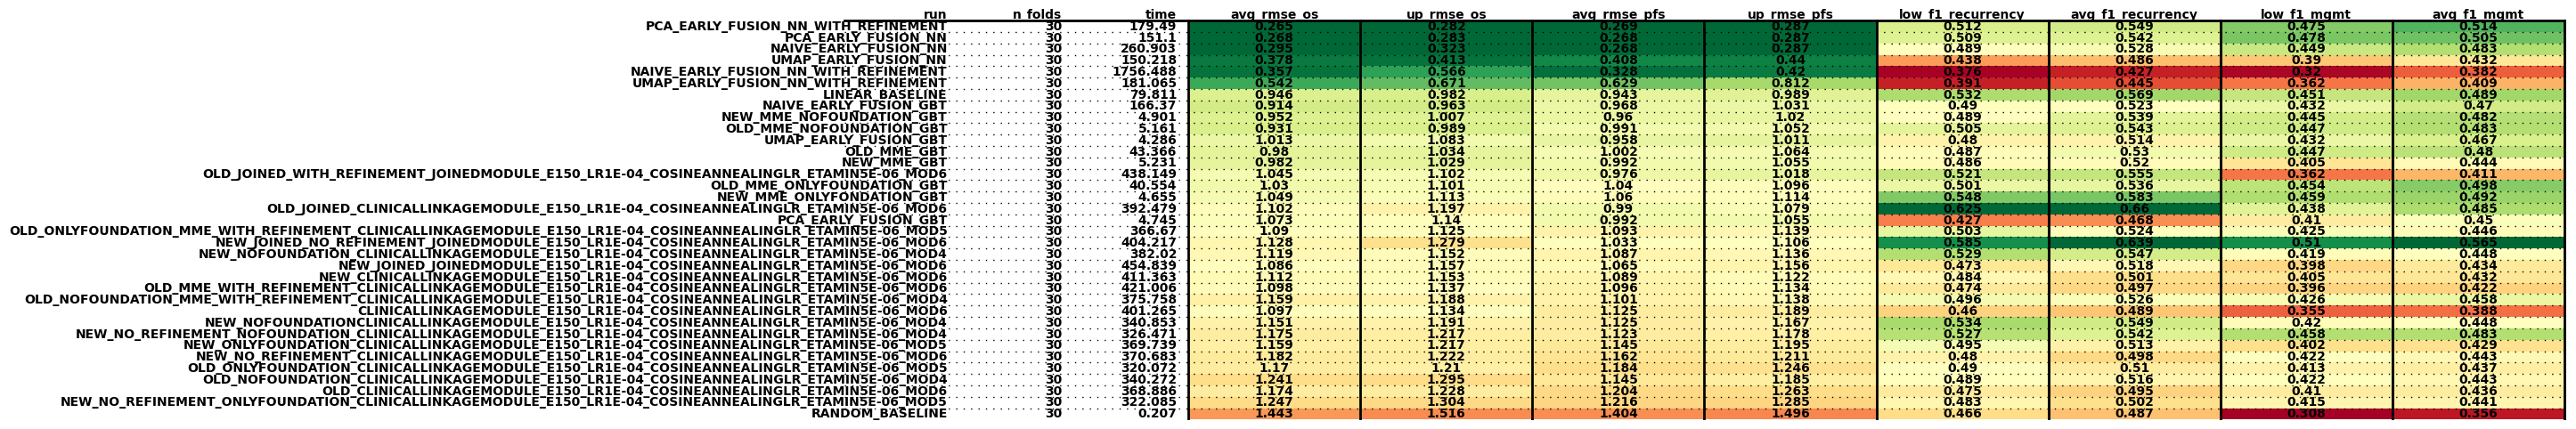

In [42]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")

In [43]:
save_model(last_model, '../saved_models/naive_early_fusion_nn_with_refinement.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/naive_early_fusion_nn_with_refinement.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_naive_early_fusion_nn_with_refinement.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/naive_early_fusion_nn_with_refinement.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_naive_early_fusion_nn_with_refinement.ckpt'))

## **Conclusion**
The neural network performs notably better than the Gradient Boosting Tree on regression tasks in this huge dimensionality setting. Both ML and DL approaches perform poorly on classification tasks. Though achieving better validation performances for regression tasks, intermediate printing allows us to see that the network overfits (reaches much better performances on training set while validation performances hit a plateau).